DataFrame shape: (173, 30)

DataFrame head:

Number of duplicate Topic Quotes: 0

--- Theme Saturation Table ---
   Participant  Cumulative Unique Themes  Percent New Themes
0          1.0                        12            1.000000
1         10.0                        16            0.363636
2          2.0                        21            0.312500
3          3.0                        22            0.083333
4          4.0                        23            0.058824
5          5.0                        23            0.000000
6          6.0                        23            0.000000
7          7.0                        23            0.000000
8          8.0                        23            0.000000
9          9.0                        23            0.000000
10         nan                        23            0.000000

Estimated saturation reached at Participant: 5.0 (Percent New Themes <= 5%)


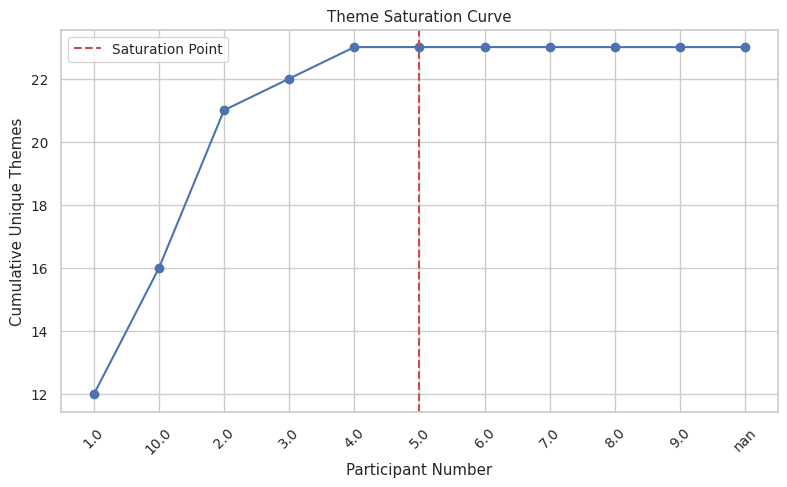

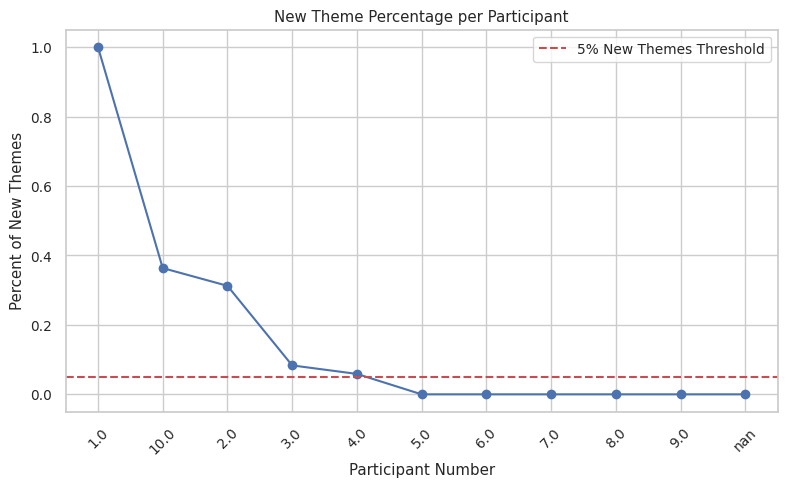

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load the Excel file ---
df = pd.read_excel("cleaned_underwriter_output.xlsx")

# --- Identify one-hot factor columns ---
one_hot_cols = df.columns[7:]  # columns corresponding to TAWE factors

# --- Basic info ---
print("DataFrame shape:", df.shape)
print("\nDataFrame head:")


# --- Check for duplicate Topic Quotes ---
duplicate_quotes = df[df['Topic Quote'].duplicated(keep=False)]
print("\nNumber of duplicate Topic Quotes:", duplicate_quotes.shape[0])
if not duplicate_quotes.empty:
    print("\nDuplicate Quotes:")
    print(duplicate_quotes[['Topic Quote', 'Quote Number', 'Participant Number']])

# --- Ensure Participant Number is string for consistent grouping ---
df['Participant Number'] = df['Participant Number'].astype(str)

# --- Sort by participant ---
df_sorted = df.sort_values('Participant Number')

# --- Initialize tracking lists ---
cumulative_themes = []
percent_new_themes = []
participant_list = []
unique_themes_so_far = set()

# --- Iterate through participants ---
for participant, group in df_sorted.groupby('Participant Number'):
    participant_themes = set()
    
    # Identify which factors are present in this participant's quotes
    for col in one_hot_cols:
        if group[col].sum(skipna=True) > 0:
            participant_themes.add(col)
    
    new_themes = participant_themes - unique_themes_so_far
    cumulative_themes.append(len(unique_themes_so_far | participant_themes))
    percent_new_themes.append(len(new_themes) / len(participant_themes) if participant_themes else 0)
    participant_list.append(participant)
    
    # Update cumulative set
    unique_themes_so_far.update(participant_themes)

# --- Create DataFrame for saturation summary ---
saturation_df = pd.DataFrame({
    'Participant': participant_list,
    'Cumulative Unique Themes': cumulative_themes,
    'Percent New Themes': percent_new_themes
})

print("\n--- Theme Saturation Table ---")
print(saturation_df)

# --- Determine saturation point ---
threshold = 0.05  # e.g., 5% new themes
saturation_candidates = saturation_df[saturation_df['Percent New Themes'] <= threshold]
if not saturation_candidates.empty:
    saturation_point = saturation_candidates['Participant'].iloc[0]
    print(f"\nEstimated saturation reached at Participant: {saturation_point} "
          f"(Percent New Themes <= {threshold*100:.0f}%)")
else:
    print("\nSaturation threshold not reached within available participants.")

# --- Visualizations ---

# 1. Cumulative Unique Themes plot
plt.figure(figsize=(8,5))
plt.plot(saturation_df['Participant'], saturation_df['Cumulative Unique Themes'], marker='o')
if not saturation_candidates.empty:
    plt.axvline(x=saturation_point, color='r', linestyle='--', label='Saturation Point')
plt.xlabel('Participant Number')
plt.ylabel('Cumulative Unique Themes')
plt.title('Theme Saturation Curve')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Percent New Themes plot
plt.figure(figsize=(8,5))
plt.plot(saturation_df['Participant'], saturation_df['Percent New Themes'], marker='o')
plt.axhline(y=threshold, color='r', linestyle='--', label='5% New Themes Threshold')
plt.xlabel('Participant Number')
plt.ylabel('Percent of New Themes')
plt.title('New Theme Percentage per Participant')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [13]:
import pandas as pd

# Load the Excel file
df = pd.read_excel("cleaned_underwriter_output.xlsx")

# One-hot columns start from column 8 (index 7)
one_hot_cols = df.columns[7:]

# --- View shape ---
print("DataFrame shape:", df.shape)

# --- Duplicate check for Topic Quote ---
duplicate_quotes = df[df['Topic Quote'].duplicated(keep=False)]

print("\nNumber of duplicate Topic Quotes:", duplicate_quotes.shape[0])
print("\nDuplicate Quotes:")
print(duplicate_quotes[['Topic Quote', 'Quote Number', 'Participant Number']])



DataFrame shape: (173, 30)

Number of duplicate Topic Quotes: 0

Duplicate Quotes:
Empty DataFrame
Columns: [Topic Quote, Quote Number, Participant Number]
Index: []


In [3]:
# Remove exact duplicate quotes (case-sensitive) and overwrite df
df = df.drop_duplicates(subset=['Topic Quote'], keep='first').reset_index(drop=True)

print("Rows after removing duplicates:", df.shape[0])



Rows after removing duplicates: 173


In [4]:
# Basic stats
num_quotes = df.shape[0]
num_participants = df['Participant Number'].nunique()

# Frequency of main categories
category_counts = df['Category - L1'].value_counts()

# --- FIX: convert one-hot columns to numeric ---
df[one_hot_cols] = df[one_hot_cols].apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)

# Count of 1s in one-hot columns
one_hot_counts = df[one_hot_cols].sum().sort_values(ascending=False)

# Quotes per participant
quotes_per_participant = df.groupby('Participant Number')['Quote Number'].count()

# Display results
print("Total quotes:", num_quotes)
print("Total participants:", num_participants)

print("\nCategory counts:\n", category_counts)

print("\nOne-hot column counts:\n", one_hot_counts)

print("\nQuotes per participant:\n", quotes_per_participant)



Total quotes: 173
Total participants: 10

Category counts:
 Category - L1
Risks & Concerns           25
Semi Factual               25
Factual Explaination       23
Counterfactual             22
Actionability              19
Explanation Format         18
Technical Elements         17
Human Oversight Control    14
Regulatory & Complaince    10
Name: count, dtype: int64

One-hot column counts:
 Clarity and Specificity                               33
Validation and Justification of Decisions             32
Usefulness and Efficiency                             31
Collaboration between AI and Humans                   16
Emphasis on Individualized Decision Making            14
Data Integrity and Security Concerns                  10
Human Judgment, Communication, and Contextual Gaps     9
Support in Complex or Borderline Case                  9
Preference for Combined Text and Visuals               8
Professional Confidence & Judgement                    8
Other                              

In [5]:
# ---------------------------
# 4. Participant × S2 stats
# ---------------------------
# Number of S2 tags per participant
s2_per_participant = df.groupby('Participant Number')[one_hot_cols].sum()

# Total S2 tags per participant
total_s2_per_participant = s2_per_participant.sum(axis=1)

print("\nTotal S2 tags per participant:\n", total_s2_per_participant)


Total S2 tags per participant:
 Participant Number
1.0     24
2.0     29
3.0     20
4.0     33
5.0     19
6.0     17
7.0     22
8.0     29
9.0     23
10.0    18
dtype: int64


In [6]:
df.columns

Index(['Topic Quote', 'Quote Number', 'Participant Number', 'Gender',
       'Location', 'Years of Experience', 'Category - L1',
       'Manual Intervention in Complex or High-Risk Cases',
       'Collaboration between AI and Humans',
       'Model Accuracy, Validation, and Comprehensiveness"',
       'Human Judgment, Communication, and Contextual Gaps',
       'Data Integrity and Security Concerns', 'Other',
       'Data sources and inputs', 'Professional Confidence & Judgement',
       'Error Detection & Improvement', 'Decision Logic and scoring mechanics',
       'Regulation as a Mandate', 'Compliance by design',
       'Operational alignment', 'Validation and Justification of Decisions',
       'Clarity and Specificity', 'Emphasis on Individualized Decision Making',
       'Usefulness and Efficiency', 'Support in Complex or Borderline Case',
       'Preference for Combined Text and Visuals',
       'Graphical Clarity and Ease of Interpretation',
       'Textual Detail for Depth and

In [7]:
df.head()

,Topic Quote,Quote Number,Participant Number,Gender,Location,Years of Experience,Category - L1,Manual Intervention in Complex or High-Risk Cases,Collaboration between AI and Humans,"Model Accuracy, Validation, and Comprehensiveness""",...,Validation and Justification of Decisions,Clarity and Specificity,Emphasis on Individualized Decision Making,Usefulness and Efficiency,Support in Complex or Borderline Case,Preference for Combined Text and Visuals,Graphical Clarity and Ease of Interpretation,Textual Detail for Depth and Context,Interactive and Feedback-Enabled Systems,Scenario based explanations
0,"But for a higher number, definitely we need a ...",43,5.0,M,Europe,12.0,Human Oversight Control,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,"But in decision making - clearly, I think it h...",44,1.0,M,Europe,4.0,Human Oversight Control,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,For exceptions that a manual underwrite would ...,45,4.0,F,US,20.0,Human Oversight Control,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,I feel like if AI is not a human being AI can'...,46,2.0,F,US,15.0,Human Oversight Control,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,"See, the underwriting process is a very comple...",47,8.0,M,India,10.0,Human Oversight Control,1,0,0,...,0,0,0,0,0,0,0,0,0,0


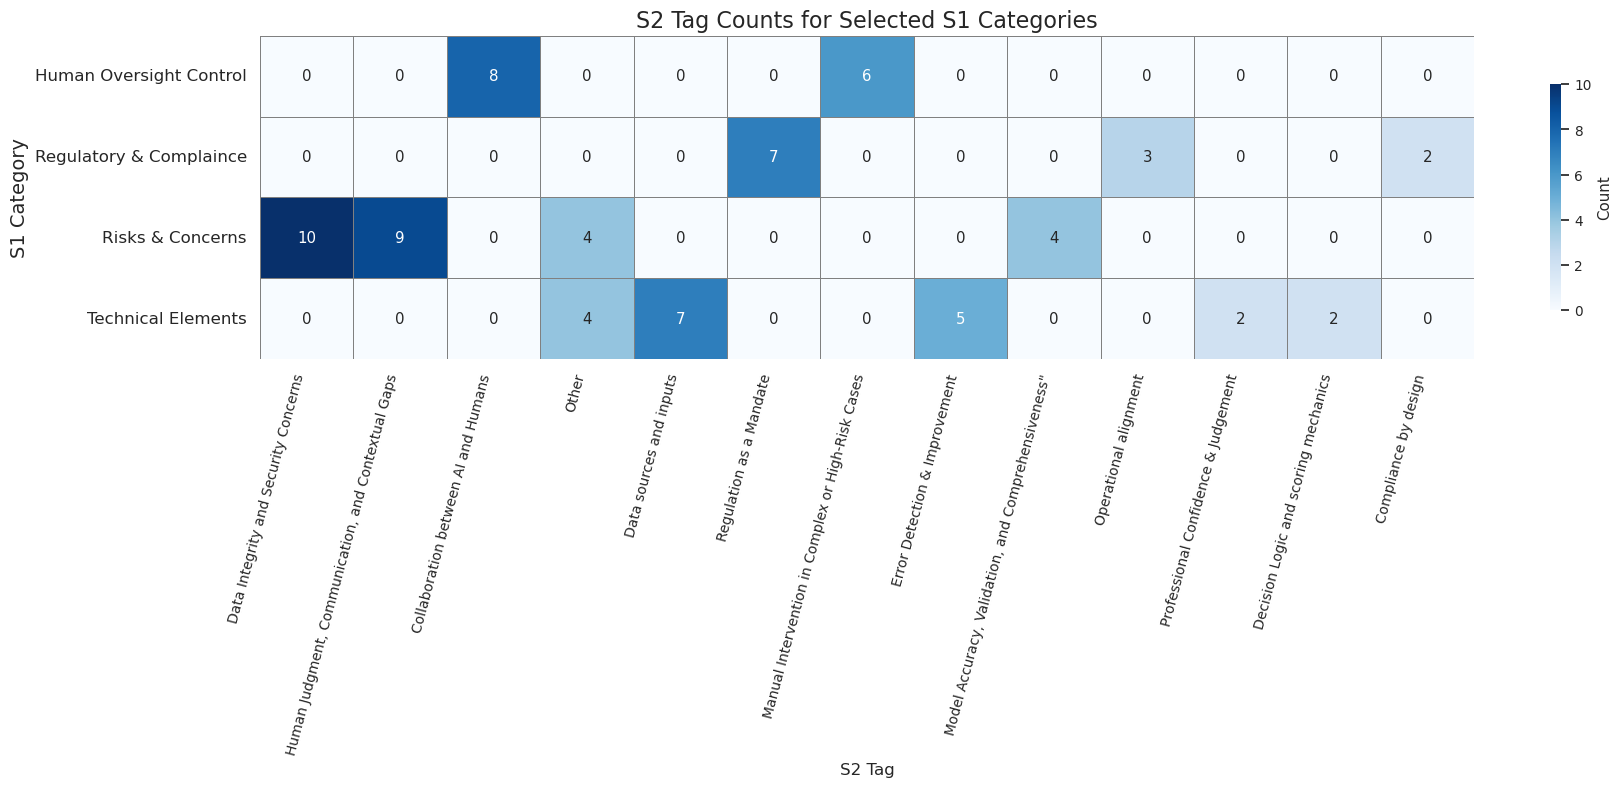

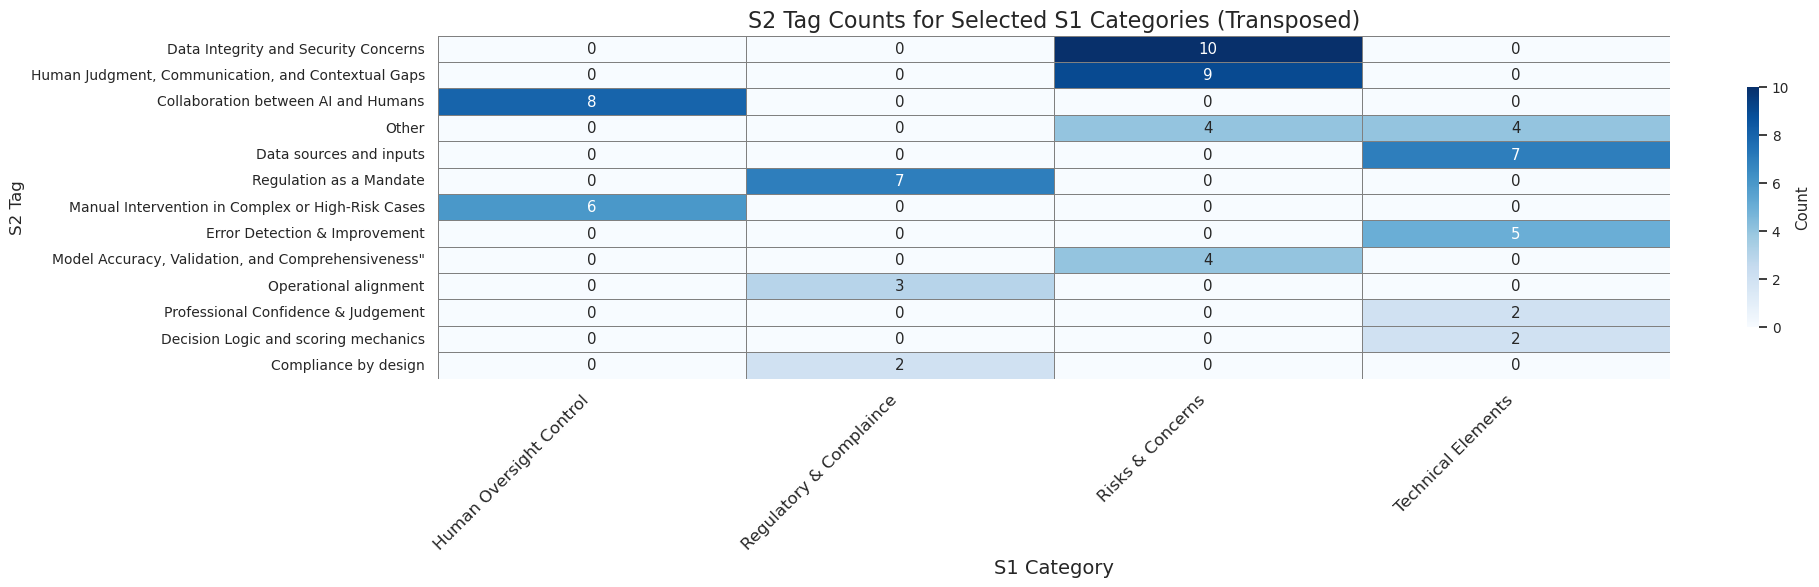

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", font_scale=0.9)

# Focused S1 categories
focus_categories = [
    'Human Oversight Control',
    'Risks & Concerns',
    'Technical Elements',
    'Regulatory & Complaince'
]

# Filter the dataframe for these S1 categories
df_focus = df[df['Category - L1'].isin(focus_categories)]

# Sum counts of each S2 tag
s2_counts = df_focus[one_hot_cols].sum()

# Keep only columns with at least one count
s2_counts = s2_counts[s2_counts > 0]

# Order S2 columns by total counts (descending)
ordered_s2 = s2_counts.sort_values(ascending=False).index

# Build heatmap DataFrame: rows=S1, columns=S2
heatmap_df = df_focus.groupby('Category - L1')[ordered_s2].sum()

# --- Option 1: Normal heatmap with larger figure and y-axis font ---
plt.figure(figsize=(18, 8))  # wider figure
sns.heatmap(
    heatmap_df, 
    annot=True, fmt="d", 
    cmap="Blues", 
    linewidths=0.5, linecolor='gray',
    cbar_kws={"shrink": 0.7, "label": "Count"}
)

plt.title("S2 Tag Counts for Selected S1 Categories", fontsize=16)
plt.ylabel("S1 Category", fontsize=14)
plt.xlabel("S2 Tag", fontsize=12)

plt.xticks(rotation=75, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=12)  # horizontal y-axis labels for readability

plt.tight_layout()
plt.show()

# --- Option 2: Transpose heatmap (makes S1 labels on x-axis) ---
plt.figure(figsize=(20, 6))
sns.heatmap(
    heatmap_df.T,  # transpose
    annot=True, fmt="d",
    cmap="Blues", linewidths=0.5, linecolor='gray',
    cbar_kws={"shrink": 0.7, "label": "Count"}
)
plt.title("S2 Tag Counts for Selected S1 Categories (Transposed)", fontsize=16)
plt.xlabel("S1 Category", fontsize=14)
plt.ylabel("S2 Tag", fontsize=12)

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()


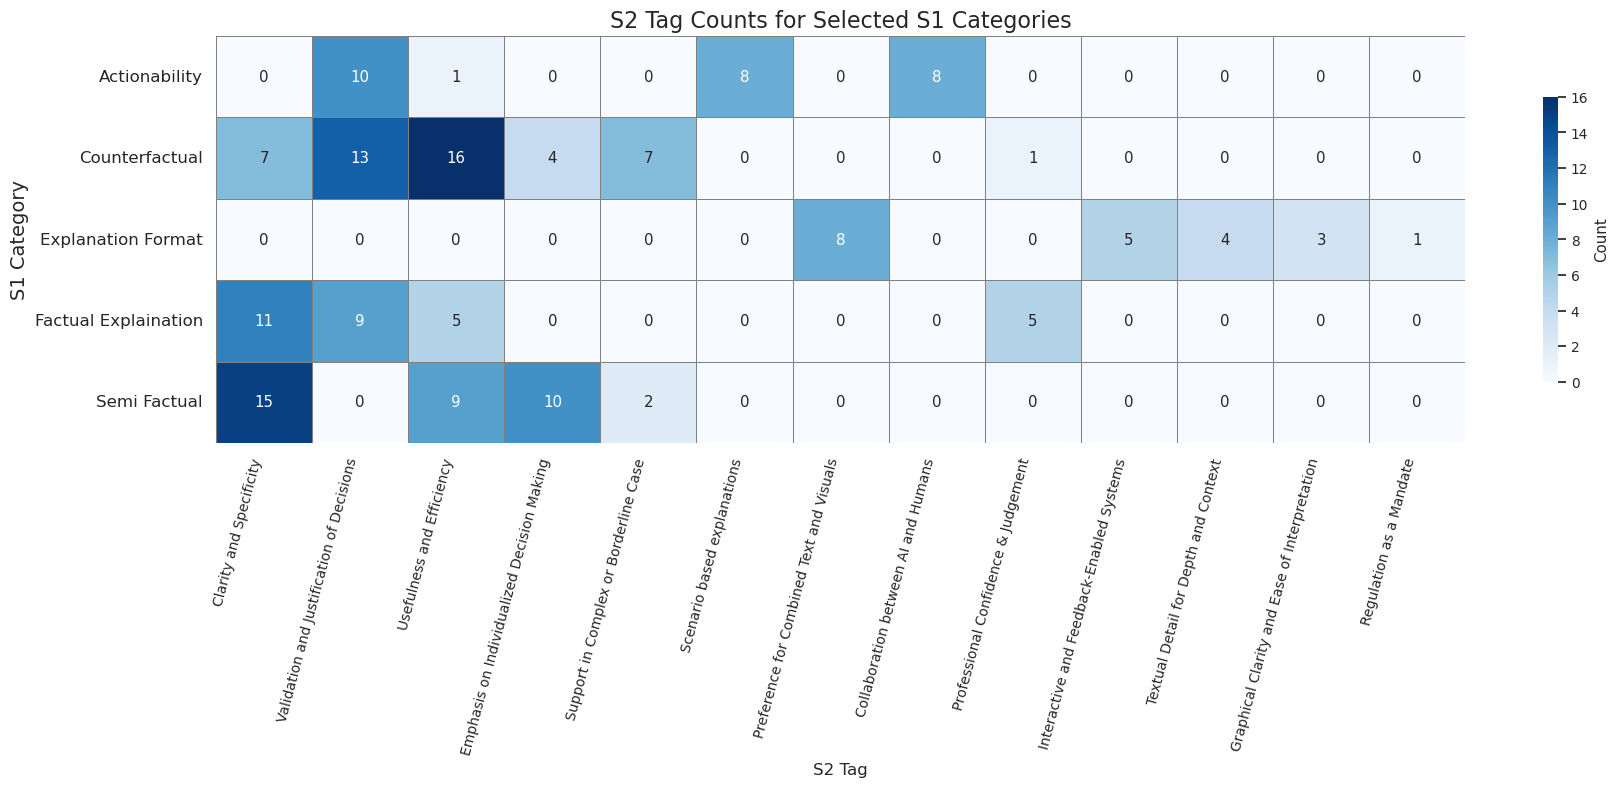

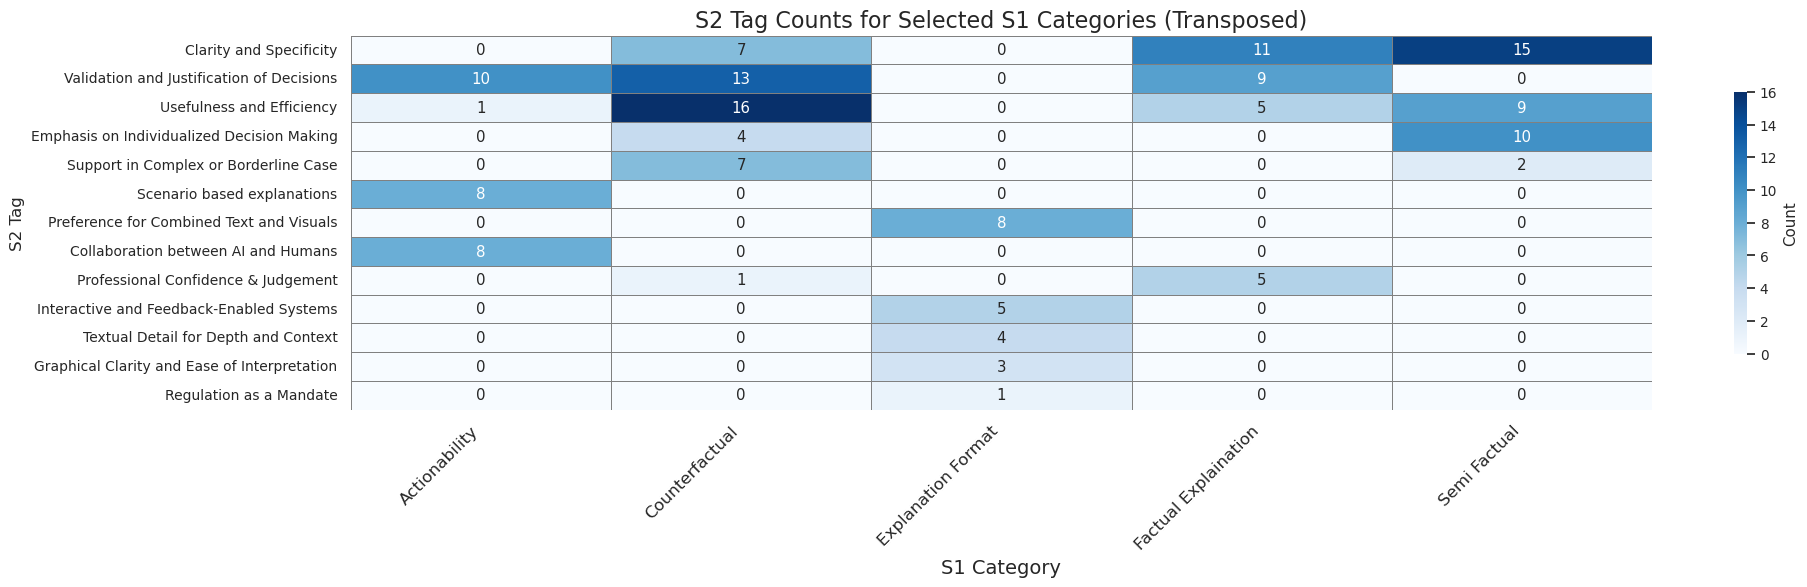

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", font_scale=0.9)

# Focused S1 categories
focus_categories = [
    'Semi Factual',
    'Factual Explaination',
    'Counterfactual',
    'Explanation Format',
    'Actionability'
]

# Filter the dataframe for these S1 categories
df_focus = df[df['Category - L1'].isin(focus_categories)]

# Sum counts of each S2 tag
s2_counts = df_focus[one_hot_cols].sum()

# Keep only columns with at least one count
s2_counts = s2_counts[s2_counts > 0]

# Order S2 columns by total counts (descending)
ordered_s2 = s2_counts.sort_values(ascending=False).index

# Build heatmap DataFrame: rows=S1, columns=S2
heatmap_df = df_focus.groupby('Category - L1')[ordered_s2].sum()

# --- Option 1: Normal heatmap with larger figure and y-axis font ---
plt.figure(figsize=(18, 8))  # wider figure
sns.heatmap(
    heatmap_df, 
    annot=True, fmt="d", 
    cmap="Blues", 
    linewidths=0.5, linecolor='gray',
    cbar_kws={"shrink": 0.7, "label": "Count"}
)

plt.title("S2 Tag Counts for Selected S1 Categories", fontsize=16)
plt.ylabel("S1 Category", fontsize=14)
plt.xlabel("S2 Tag", fontsize=12)

plt.xticks(rotation=75, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=12)  # horizontal y-axis labels for readability

plt.tight_layout()
plt.show()

# --- Option 2: Transpose heatmap (makes S1 labels on x-axis) ---
plt.figure(figsize=(20, 6))
sns.heatmap(
    heatmap_df.T,  # transpose
    annot=True, fmt="d",
    cmap="Blues", linewidths=0.5, linecolor='gray',
    cbar_kws={"shrink": 0.7, "label": "Count"}
)
plt.title("S2 Tag Counts for Selected S1 Categories (Transposed)", fontsize=16)
plt.xlabel("S1 Category", fontsize=14)
plt.ylabel("S2 Tag", fontsize=12)

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()


                                                        mean       std  count
Manual Intervention in Complex or High-Risk Cases  -0.016171  0.104830    6.0
Collaboration between AI and Humans                 0.131781  0.139571   16.0
Model Accuracy, Validation, and Comprehensiveness"  0.069444  0.136874    4.0
Human Judgment, Communication, and Contextual Gaps  0.068463  0.123251    9.0
Data Integrity and Security Concerns               -0.010903  0.250664   10.0
Other                                               0.041840  0.081143    8.0
Data sources and inputs                             0.174286  0.231938    7.0
Professional Confidence & Judgement                 0.140625  0.130888    8.0
Error Detection & Improvement                       0.152500  0.266985    5.0
Decision Logic and scoring mechanics               -0.018750  0.026517    2.0
Regulation as a Mandate                             0.093027  0.194478    8.0
Compliance by design                                0.000000  0.

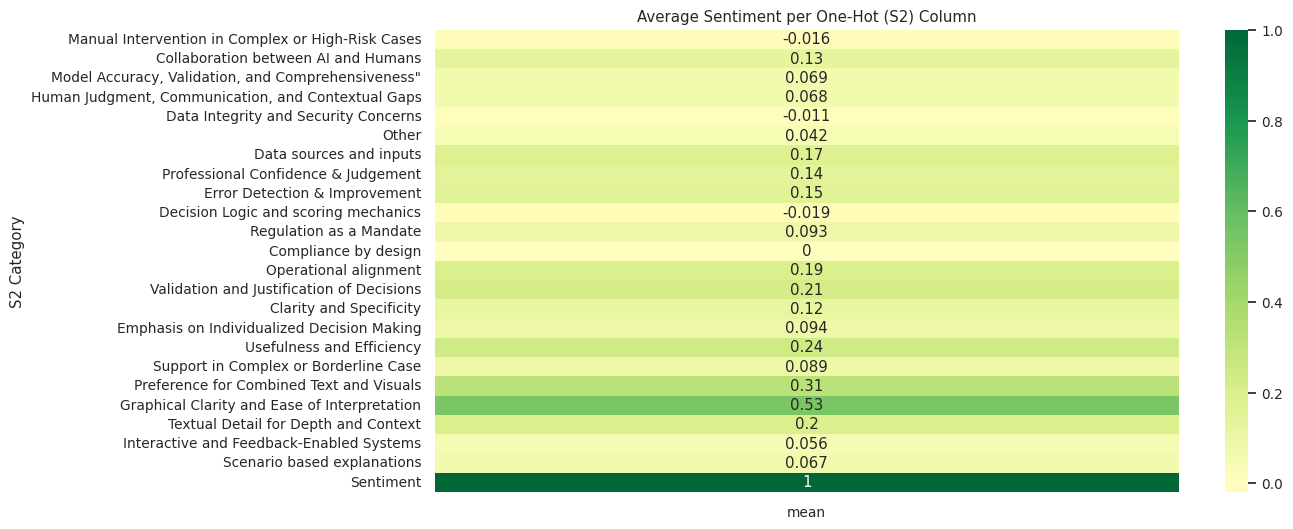

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob


# Ensure quotes are string
df['Topic Quote'] = df['Topic Quote'].astype(str)

# One-hot columns (S2) start from column 8
one_hot_cols = df.columns[7:]

# Calculate sentiment for each quote
df['Sentiment'] = df['Topic Quote'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Aggregate sentiment per one-hot column
sentiment_per_s2 = {}
for col in one_hot_cols:
    # Only consider quotes where column == 1
    subset = df[df[col] == 1]['Sentiment']
    if not subset.empty:
        sentiment_per_s2[col] = {
            'mean': subset.mean(),
            'std': subset.std(),
            'count': subset.count()
        }

# Convert to DataFrame
sentiment_s2_df = pd.DataFrame(sentiment_per_s2).T

print(sentiment_s2_df)

# Heatmap of mean sentiment per S2
plt.figure(figsize=(12,6))
sns.heatmap(sentiment_s2_df[['mean']], annot=True, cmap='RdYlGn', center=0)
plt.title("Average Sentiment per One-Hot (S2) Column")
plt.ylabel("S2 Category")
plt.show()
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

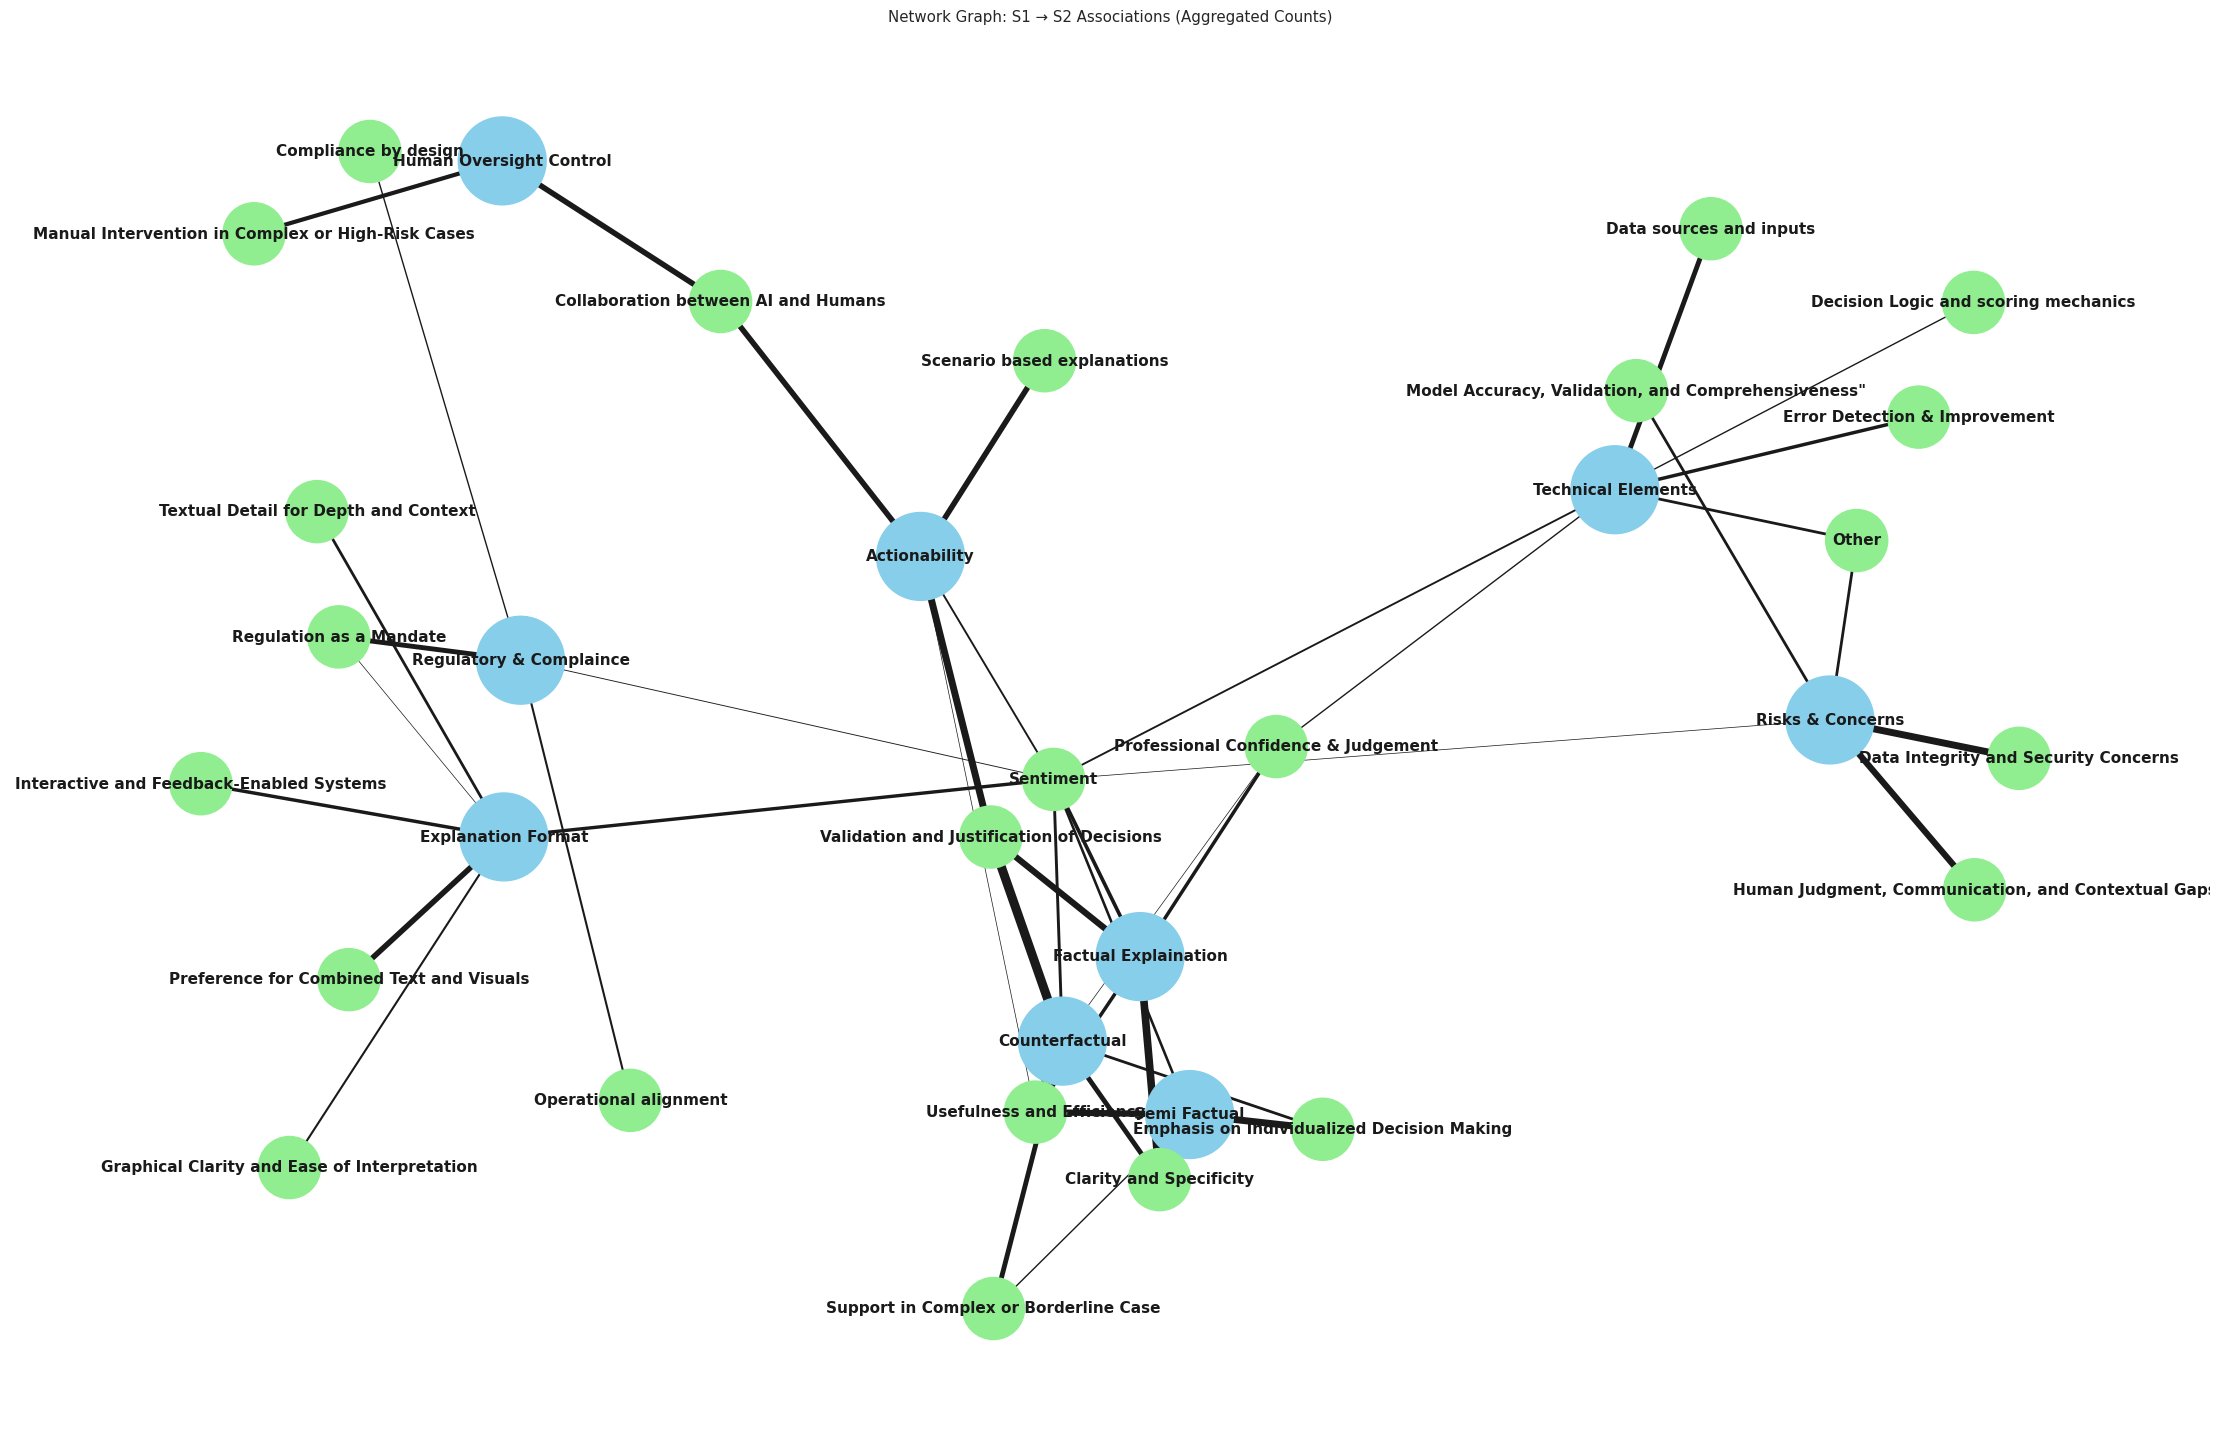

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx


# Remove rows where S1 is NaN
df = df.dropna(subset=['Category - L1'])

# One-hot columns = S2
s2_cols = df.columns[7:]  # Columns 8 onward
s1_categories = df['Category - L1'].unique()

# Optional: remove empty S2 columns (all zeros)
s2_cols = [col for col in s2_cols if df[col].sum() > 0]

# -----------------------------
# 2. Aggregate counts by S1
# -----------------------------
s1_s2_counts = df.groupby('Category - L1')[s2_cols].sum()

# -----------------------------
# 5. Network graph S1 → S2
# -----------------------------
G = nx.Graph()

# Add S1 nodes
for s1 in s1_categories:
    G.add_node(s1, type='S1')

# Add S2 nodes
for s2 in s2_cols:
    G.add_node(s2, type='S2')

# Add edges weighted by aggregated counts
for s1 in s1_categories:
    for s2 in s2_cols:
        weight = s1_s2_counts.loc[s1, s2]
        if weight > 0:
            G.add_edge(s1, s2, weight=weight)

# Spread nodes widely using spring layout
pos = nx.spring_layout(G, k=2.5, iterations=200)

plt.figure(figsize=(22,14))
node_colors = ['skyblue' if G.nodes[n]['type']=='S1' else 'lightgreen' for n in G.nodes()]
node_sizes = [4000 if G.nodes[n]['type']=='S1' else 2000 for n in G.nodes()]
edge_widths = [G[u][v]['weight']*0.5 for u,v in G.edges()]

nx.draw(G, pos, with_labels=True, node_color=node_colors,
        node_size=node_sizes, font_size=11, font_weight='bold',
        width=edge_widths)

plt.title("Network Graph: S1 → S2 Associations (Aggregated Counts)")
plt.show()



In [26]:
import pandas as pd

tech_trust_df = pd.DataFrame({
    'Participant Number': [2, 9, 7, 6, 8, 1, 4, 3, 10, 5],
    'TechTrust': [
        0.048250,
        0.072905,
        0.185188,
        0.113904,
        0.129216,
        0.159183,
        0.096558,
        0.096386,
        0.135985,
        0.078186
    ]
})

tech_trust_df


,Participant Number,TechTrust
0,2,0.048250
1,9,0.072905
2,7,0.185188
3,6,0.113904
4,8,0.129216
5,1,0.159183
6,4,0.096558
7,3,0.096386
8,10,0.135985
9,5,0.078186


In [27]:
import pandas as pd
from textblob import TextBlob
import numpy as np

# Ensure quotes are string
df['Topic Quote'] = df['Topic Quote'].astype(str)

# Ensure Participant Number is valid
df = df.dropna(subset=['Participant Number'])
df['Participant Number'] = df['Participant Number'].astype(str)

# Calculate sentiment for each quote
df['Sentiment'] = df['Topic Quote'].apply(lambda x: TextBlob(x).sentiment.polarity)

# --- Aggregate per participant per Category_L1 ---
participant_theme_list = []

for participant, pdata in df.groupby('Participant Number'):
    for category, cdata in pdata.groupby('Category - L1'):
        mean_sentiment = cdata['Sentiment'].mean()
        quote_count = cdata.shape[0]
        participant_theme_list.append({
            'Participant Number': participant,
            'Category - L1': category,
            'Mean_Sentiment': mean_sentiment,
            'Quote_Count': quote_count
        })

# Convert to DataFrame
participant_theme_dfL1 = pd.DataFrame(participant_theme_list)

# Optional: pivot to wide format for easier analysis/merging with trust scores
participant_sentiment_wide = participant_theme_dfL1.pivot(
    index='Participant Number', 
    columns='Category - L1', 
    values='Mean_Sentiment'
).reset_index()

participant_count_wide = participant_theme_dfL1.pivot(
    index='Participant Number',
    columns='Category - L1',
    values='Quote_Count'
).reset_index()

# View results
print(participant_theme_dfL1.head())
print(participant_sentiment_wide.head())
print(participant_count_wide.head())



  Participant Number            Category - L1  Mean_Sentiment  Quote_Count
0                1.0            Actionability        0.300000            1
1                1.0           Counterfactual        0.129167            2
2                1.0       Explanation Format        0.716667            1
3                1.0     Factual Explaination        0.148469            2
4                1.0  Human Oversight Control        0.050000            1
Category - L1 Participant Number  Actionability  Counterfactual  \
0                            1.0       0.300000        0.129167   
1                           10.0       0.300000        0.350000   
2                            2.0       0.109375        0.050000   
3                            3.0       0.018750        0.234167   
4                            4.0       0.155625        0.101984   

Category - L1  Explanation Format  Factual Explaination  \
0                        0.716667              0.148469   
1                        0.70

In [49]:
def clean_ids(df):
    df['Participant Number'] = (
        df['Participant Number']
        .astype(str)
        .str.strip()
        .str.replace(r'\.0$', '', regex=True)   # Remove .0
    )
    return df

tech_trust_df = clean_ids(tech_trust_df)
participant_sentiment_wide = clean_ids(participant_sentiment_wide)
participant_count_wide = clean_ids(participant_count_wide)


In [50]:
import pandas as pd
from scipy.stats import spearmanr

# --- Merge with TechTrust ---
# Ensure Participant Number columns are strings
tech_trust_df['Participant Number'] = tech_trust_df['Participant Number'].astype(str)
participant_sentiment_wide['Participant Number'] = participant_sentiment_wide['Participant Number'].astype(str)
participant_count_wide['Participant Number'] = participant_count_wide['Participant Number'].astype(str)

# Merge sentiment
merged_sentiment = participant_sentiment_wide.merge(
    tech_trust_df[['Participant Number', 'TechTrust']],
    on='Participant Number',
    how='inner'
)

# Merge counts
merged_counts = participant_count_wide.merge(
    tech_trust_df[['Participant Number', 'TechTrust']],
    on='Participant Number',
    how='inner'
)


In [56]:
from scipy.stats import shapiro
import pandas as pd
import numpy as np

def shapiro_test(df, columns):
    results = []

    for col in columns:
        data = df[col].dropna()

        # Not enough data for Shapiro-Wilk
        if len(data) < 3:
            results.append({
                "Variable": col,
                "N": len(data),
                "Shapiro_W": np.nan,
                "p_value": np.nan,
                "Normality": "Insufficient data"
            })
            continue

        # Perform the test
        W, p = shapiro(data)

        # Categorize normality
        if p >= 0.05:
            normality = "Normal"
        else:
            normality = "Non-normal"

        results.append({
            "Variable": col,
            "N": len(data),
            "Shapiro_W": W,
            "p_value": p,
            "Normality": normality
        })

    # Return nice clean dataframe
    return pd.DataFrame(results)


In [57]:
shapiro_sentiment = shapiro_test(merged_sentiment, sentiment_cols)
print(shapiro_sentiment)


                  Variable   N  Shapiro_W   p_value   Normality
0            Actionability   9   0.878562  0.151636      Normal
1           Counterfactual  10   0.946971  0.632819      Normal
2       Explanation Format  10   0.814987  0.022038  Non-normal
3     Factual Explaination  10   0.880436  0.132005      Normal
4  Human Oversight Control  10   0.928707  0.435298      Normal
5  Regulatory & Complaince   9   0.662360  0.000515  Non-normal
6         Risks & Concerns  10   0.952177  0.694291      Normal
7             Semi Factual  10   0.863126  0.083057      Normal
8       Technical Elements  10   0.827157  0.030922  Non-normal


In [60]:
from scipy.stats import pearsonr
import pandas as pd
import numpy as np

def pearson_vs_techtrust(df, target="TechTrust"):
    results = []
    
    # all columns except participant and tech trust
    sentiment_cols = [c for c in df.columns if c not in ["Participant Number", target]]
    
    for col in sentiment_cols:
        x = df[col].astype(float)
        y = df[target].astype(float)
        
        # Remove NaN pairs
        mask = ~x.isna() & ~y.isna()
        
        if mask.sum() > 1:
            r, p = pearsonr(x[mask], y[mask])
        else:
            r, p = np.nan, np.nan
        
        results.append({
            "Variable": col,
            "Pearson_r": r,
            "p_value": p,
            "N": mask.sum()
        })
    
    pearson_df = pd.DataFrame(results)
    
    # Sort by absolute correlation
    pearson_df = pearson_df.sort_values(by="Pearson_r", key=lambda s: s.abs(), ascending=False)
    
    return pearson_df


In [61]:
pearson_sentiment_results = pearson_vs_techtrust(merged_sentiment)
pearson_sentiment_results


,Variable,Pearson_r,p_value,N
5,Regulatory & Complaince,0.684617,0.041902,9
7,Semi Factual,0.604991,0.063866,10
2,Explanation Format,0.537768,0.108866,10
0,Actionability,0.506266,0.164317,9
8,Technical Elements,0.367690,0.295882,10
4,Human Oversight Control,-0.289586,0.417034,10
1,Counterfactual,0.246325,0.492686,10
3,Factual Explaination,-0.237929,0.508007,10
6,Risks & Concerns,0.066516,0.855139,10


In [62]:
# --- Compute Spearman correlations ---
def compute_spearman(df, value_cols, target='TechTrust'):
    results = []
    for col in value_cols:
        x = df[col].values
        y = df[target].values
        # Only keep non-NaN pairs
        mask = ~pd.isna(x) & ~pd.isna(y)
        if mask.sum() > 1:  # need at least 2 points
            rho, pval = spearmanr(x[mask], y[mask])
        else:
            rho, pval = float('nan'), float('nan')
        results.append({
            'Predictor': col,
            'Spearman_rho': rho,
            'Spearman_p': pval
        })
    return pd.DataFrame(results)

# Columns to test
sentiment_cols = [c for c in merged_sentiment.columns if c not in ['Participant Number', 'TechTrust']]
count_cols = [c for c in merged_counts.columns if c not in ['Participant Number', 'TechTrust']]

# Spearman correlations
spearman_sentiment_df = compute_spearman(merged_sentiment, sentiment_cols)
spearman_counts_df = compute_spearman(merged_counts, count_cols)

# Optional: sort by absolute correlation
spearman_sentiment_df = spearman_sentiment_df.sort_values(by='Spearman_rho', key=abs, ascending=False)
spearman_counts_df = spearman_counts_df.sort_values(by='Spearman_rho', key=abs, ascending=False)

# Display
print("=== Sentiment Correlations ===")
print(spearman_sentiment_df)
print("\n=== Count Correlations ===")
print(spearman_counts_df)


=== Sentiment Correlations ===
                 Predictor  Spearman_rho  Spearman_p
5  Regulatory & Complaince      0.861684    0.002823
0            Actionability      0.661094    0.052523
2       Explanation Format      0.624242    0.053718
7             Semi Factual      0.515152    0.127553
1           Counterfactual      0.321212    0.365468
3     Factual Explaination     -0.309091    0.384841
4  Human Oversight Control     -0.143820    0.691820
8       Technical Elements      0.112555    0.756882
6         Risks & Concerns     -0.066870    0.854375

=== Count Correlations ===
                 Predictor  Spearman_rho  Spearman_p
0            Actionability     -0.816922    0.007192
7             Semi Factual      0.543067    0.104753
2       Explanation Format     -0.422116    0.224307
5  Regulatory & Complaince      0.273861    0.475797
8       Technical Elements     -0.160806    0.657193
4  Human Oversight Control      0.157313    0.664268
6         Risks & Concerns      0.132170

In [63]:
from statsmodels.stats.multitest import multipletests

def apply_multiple_testing(df, p_col='Spearman_p'):
    df = df.copy()
    
    # Extract p-values
    pvals = df[p_col].values.astype(float)
    
    # Ignore NaN
    valid_mask = ~pd.isna(pvals)
    valid_p = pvals[valid_mask]

    # ---- Run corrections ----
    bonf = multipletests(valid_p, method='bonferroni')
    holm = multipletests(valid_p, method='holm')
    bh   = multipletests(valid_p, method='fdr_bh')

    # ---- Create new columns ----
    df['p_bonf'] = np.nan
    df['p_holm'] = np.nan
    df['p_bh'] = np.nan
    
    df.loc[valid_mask, 'p_bonf'] = bonf[1]
    df.loc[valid_mask, 'p_holm'] = holm[1]
    df.loc[valid_mask, 'p_bh'] = bh[1]

    # ---- Add significance flags ----
    df['sig_bonf'] = df['p_bonf'] < 0.05
    df['sig_holm'] = df['p_holm'] < 0.05
    df['sig_bh'] = df['p_bh'] < 0.05
    
    return df


In [64]:
sentiment_corrected = apply_multiple_testing(spearman_sentiment_df)
counts_corrected = apply_multiple_testing(spearman_counts_df)


In [65]:
print("\n=== Sentiment Spearman (with correction) ===")
print(sentiment_corrected)

print("\n=== Count Spearman (with correction) ===")
print(counts_corrected)



=== Sentiment Spearman (with correction) ===
                 Predictor  Spearman_rho  Spearman_p    p_bonf    p_holm  \
5  Regulatory & Complaince      0.861684    0.002823  0.025406  0.025406   
0            Actionability      0.661094    0.052523  0.472706  0.420183   
2       Explanation Format      0.624242    0.053718  0.483460  0.420183   
7             Semi Factual      0.515152    0.127553  1.000000  0.765317   
1           Counterfactual      0.321212    0.365468  1.000000  1.000000   
3     Factual Explaination     -0.309091    0.384841  1.000000  1.000000   
4  Human Oversight Control     -0.143820    0.691820  1.000000  1.000000   
8       Technical Elements      0.112555    0.756882  1.000000  1.000000   
6         Risks & Concerns     -0.066870    0.854375  1.000000  1.000000   

       p_bh  sig_bonf  sig_holm  sig_bh  
5  0.025406      True      True    True  
0  0.161153     False     False   False  
2  0.161153     False     False   False  
7  0.286994     False    